#### Carnegie Mellon University - Tepper School of Business
#### 46-886 - Machine Learning Fundamentals
#### 22/23 - Mini 4 - Sections M4 - Farahat

---

### FINAL EXAM
**Due Sunday, April 30th at 11:59 p.m. (Pittsburgh time)**

*This exam consists of **three** problems. Save a copy of this notebook and provide your solutions by inserting code or markdown text cells as appropriate. Use Python code only.*

*Accompanying datasets are posted on Canvas under the exam's Assignment page.*

*Use a random state equal to 886 for any code that requires a random_state parameter.*

*You will need to submit two files through Canvas: 1) a completed Jupyter notebook (extension .ipynb) with your code and answers to each question (this file); and 2) an html rendering of your completed Jupyter notebook.*

*Work individually! No collaboration whatsoever is allowed.*

*If you feel a clarification is required, email me and cc Flora. If I feel a clarification is warranted, I will reply to your email and (anonymously) include the clarification in this google document:*

https://docs.google.com/document/d/12IeSWm-01YL47KDZnOPGOvg6s0u6ZqJD_rQu_LJP240/edit?usp=sharing

---

### PROBLEM 1 (25 points)

The file <mall_customers.csv> is a synthetic dataset containing characteristics of 200 shoppers at a Mall (source: Kaggle). Such data is typically collected by retailers through a store loyalty card. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scikitplot as skplt

In [2]:
pd.options.display.max_columns = None

In [3]:
df = pd.read_csv("mall_customers.csv")

### Data Exploration

In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Removing CustomerID as there is no direct relation to segmenting customers.
# Customer Segmentation will be based on Age, Annual Income and Spending Score.

df.drop(["CustomerID"], axis = 1, inplace=True)

Text(0.5, 1.0, 'Age vs Annual Income')

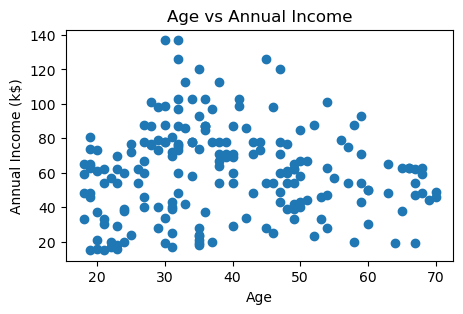

In [8]:
plt.figure(figsize=(5,3))
plt.scatter(df['Age'],df['Annual Income (k$)'], marker='o');
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Age vs Annual Income')

Text(0.5, 1.0, 'Age vs Spending Score')

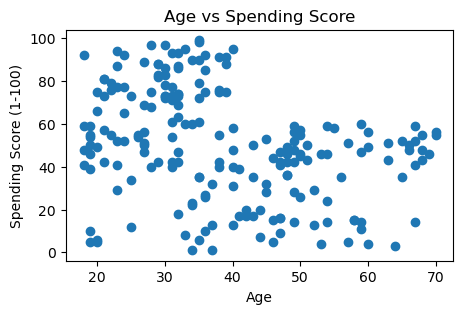

In [9]:
plt.figure(figsize=(5,3))
plt.scatter(df['Age'],df['Spending Score (1-100)'], marker='o');
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Age vs Spending Score')

Text(0.5, 1.0, 'Annual Income vs Spending Score')

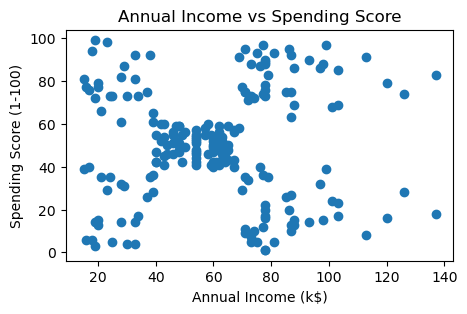

In [10]:
plt.figure(figsize=(5,3))
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'], marker='o');
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')

### Standardizing the data

In [11]:
# Standardizing only 'Age', 'Annual Income (k$)','Spending Score (1-100)' columns.
# Gender is a Categorical variable and needs to be encoded 

col_names = ['Age', 'Annual Income (k$)','Spending Score (1-100)']
features = df[col_names]

In [12]:
scaler = StandardScaler()

In [13]:
scaler.fit(features.values)

StandardScaler()

In [14]:
features = scaler.transform(features.values)

In [15]:
scaled_features = pd.DataFrame(features, columns = col_names)


In [16]:
scaled_features

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


In [17]:
#One Hot Encoding

gender = df['Gender']
newdf = scaled_features.join(gender)

In [18]:
newdf = pd.get_dummies(newdf, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False, dtype=None)
newdf = newdf.drop(['Gender_Male'],axis=1)
newdf

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female
0,-1.424569,-1.738999,-0.434801,0
1,-1.281035,-1.738999,1.195704,0
2,-1.352802,-1.700830,-1.715913,1
3,-1.137502,-1.700830,1.040418,1
4,-0.563369,-1.662660,-0.395980,1
...,...,...,...,...
195,-0.276302,2.268791,1.118061,1
196,0.441365,2.497807,-0.861839,1
197,-0.491602,2.497807,0.923953,0
198,-0.491602,2.917671,-1.250054,0


In [19]:
newdf.mean()

Age                      -1.021405e-16
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
Gender_Female             5.600000e-01
dtype: float64

In [20]:
newdf.std()

Age                       1.002509
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
Gender_Female             0.497633
dtype: float64

#### Part (a) (20 points)

Create an appropriate customer segmentation using k-means clustering with k=4. Provide the centroids of the four clusters and the percent reduction in inertia compared to a single cluster.

#### Setting k=1

In [21]:
k1=1

In [22]:
clustering_kmeans = KMeans(n_clusters=k1, n_init=10,random_state=886)
clustering_kmeans.fit(newdf)

KMeans(n_clusters=1, n_init=10, random_state=886)

In [23]:
inertia1 = clustering_kmeans.inertia_
inertia1

649.28

In [24]:
clustering_kmeans.cluster_centers_

array([[-1.60427227e-16, -4.04121181e-16, -5.77315973e-17,
         5.60000000e-01]])

#### Setting k=4

In [25]:
k2=4

In [26]:
clustering_kmeans = KMeans(n_clusters=k2, n_init=10,random_state=886)
clustering_kmeans.fit(newdf)

KMeans(n_clusters=4, n_init=10, random_state=886)

In [27]:
inertia2 = clustering_kmeans.inertia_
inertia2

254.3464209020765

In [28]:
clustering_kmeans.cluster_centers_

array([[ 0.03985961,  1.01332613, -1.21228193,  0.48648649],
       [-0.96249203, -0.78476346,  0.39202966,  0.59649123],
       [ 1.06877999, -0.481143  , -0.39597992,  0.57575758],
       [-0.42880597,  0.97484722,  1.21608539,  0.55      ]])

#### Percentage Reduction in Inertia

In [29]:
perc_reduction_inertia = (inertia1 - inertia2)/inertia1
print(perc_reduction_inertia * 100,'%')

60.826389092213454 %


#### Part (b) (5 points)

Provide a simple description, or descriptive label, to each of the segments/clusters you’ve identified in Part (a). Use an appropriate plot.

In [30]:
df_centroids = pd.DataFrame(clustering_kmeans.cluster_centers_, columns=newdf.columns)
df_centroids

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female
0,0.039860,1.013326,-1.212282,0.486486
1,-0.962492,-0.784763,0.392030,0.596491
2,1.068780,-0.481143,-0.395980,0.575758
3,-0.428806,0.974847,1.216085,0.550000


<Axes: >

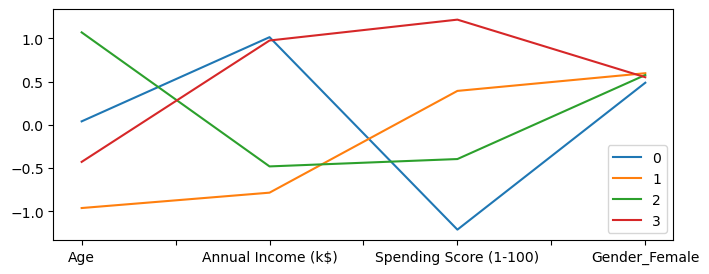

In [31]:
df_centroids.T.plot(figsize = (8,3))

### Explanation

#### Cluster 0 - This Cluster represents shoppers with median age, highest income and the lowest spending score.

#### Cluster 1 - This Cluster represents shoppers who are young, earn the lowest income, but have above average spending score.

#### Cluster 2 - This Cluster represents shoppers who are aged, earn average income and have average spending score.

#### Cluster 3 - This Cluster represents shoppers who are median age, earn high income, and highest spending score.

---

### PROBLEM 2 (50 points)

Cardiovascular (heart) disease is a major health problem worldwide.  It is estimated that by 2030, over 23 million people will die from cardiovascular diseases each year globally, with the impact disproportionally affecting low and middle-income countries.

In the late 1940s, the U.S. government took steps to study heart disease. In order to develop excellent data for their study, they decided to track a large cohort of initially-healthy people over time. The town of Framingham, Massachusetts (a suburb of Boston) was selected as the site for the study, which commenced in 1948. The study enrolled 5,209 participants aged 30-62. Participants were given a questionnaire and a medical exam every two years.  They also collected data on the participants' physical characteristics and behavioral characteristics in addition to the medical test data. Over the years, the study has expanded to include multiple generations and has collected many more factors including genetic information.  This data is now famously known and is simply called the **Framingham Heart Study**.

In this problem (adapted from a question developed at MIT), I ask you to construct a predictive model using the Framingham Heart Study data in order to predict coronary heart disease (CHD) and to make recommendations to better prevent it. 

There are 3,658 observations, with each observation representing the data from a particular study participant. There are 16 columns in the dataset, which are described in the table below. The train and test datasets are available on Canvas and labelled <fhs_train.csv>  and <fhs_test.csv>, respectively. 

| Column name     |	Description |
| :---------------| :------------------|
| male	          | Gender of patient|
| age	          | Age (in years) at first examination|
| education	      | Some high school, high school/GED, some college/vocational school, college|
| currentSmoker	  | Is a current smoker|
| cigsPerDay      |	Number of cigarettes per day|
| BPMeds          |	Is on blood pressure medication at time of first examination|
| prevalentStroke |	Previously had a stroke|
| prevalentHyp    |	Currently hypertensive|
| diabetes        |	Currently has diabetes|
| totChol         |	Total cholesterol (mg/dL)|
| sysBP           |	Systolic blood pressure|
| diaBP           |	Diastolic blood pressure|
| BMI             |	Body Mass Index|
| heartRate       |	Heart rate (beats/minute)|
| glucose         |	Blood glucose level (mg/dL)|
| TenYearCHD      |	Experienced coronary heart disease within 10 years of first examination|
 
You will be asked to predict TenYearCHD (whether a patient experiences coronary heart disease within 10 years of his or her first examination). As a consequence of your modeling efforts, you should be able to identify risk factors, which are the variables that increase the risk of CHD.

To lower the risk of CHD, physicians can prescribe preventive medication such as blood-pressure lowering or cholesterol-lowering medications. Many policy makers, when recommending certain
preventive medications to patients at risk of developing CHD, rely on evidence-based analysis that
weighs the pros and cons of such interventions. Health economic evaluation is a commonly applied
methodology for decision-making that takes both medical costs and health benefits (a monetized
version of improved life longevity) into consideration. In fact, many countries establish clinical
practice guidelines using such formalized health economic evaluation methodologies (the National
Institute for Health and Clinical Excellence in England, for example).

As prior work, let us suppose that a colleague of yours has completed a health economics study
analyzing the costs and benefits of a recently approved medication aimed at preventing CHD. The
study has estimated that patients who experience CHD within the next 10 years are expected to incur
a lifetime cost of USD165,000 associated with the disease; this cost includes both the costs of treatment for CHD (USD80,000) as well as a cost intended to capture the decreased quality and length of life experienced by patients with CHD (USD85,000). The study has determined that patients who take the preventative medicine will have their probability of developing CHD within the next 10 years reduced by a factor of 2.3; that is, if their current 10-year risk of developing CHD is p without taking the medication, then their 10-year risk with the medicine would instead be p/2.3. Regardless of whether a patient eventually develops CHD, there is a USD7,500 cost associated with taking this recently approved medication.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_graphviz
from graphviz import Source
from matplotlib import pyplot

In [33]:
pd.options.display.max_columns = None

In [34]:
df_train = pd.read_csv("fhs_train.csv")
df_test = pd.read_csv("fhs_test.csv")

In [35]:
df_train.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [36]:
df_test.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [37]:
df_train

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,College,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,0
1,0,46,High school/GED,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0
2,1,48,Some high school,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0
3,0,61,Some college/vocational school,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1
4,0,46,Some college/vocational school,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2739,1,50,Some high school,1,1,0,0,1,0,313,179.0,92.0,25.97,66,86,1
2740,1,51,Some college/vocational school,1,43,0,0,0,0,207,126.5,80.0,19.71,65,68,0
2741,0,52,High school/GED,0,0,0,0,0,0,269,133.5,83.0,21.47,80,107,0
2742,1,40,Some college/vocational school,0,0,0,0,1,0,185,141.0,98.0,25.60,67,72,0


In [38]:
df_train = pd.get_dummies(df_train)
df_test = pd.get_dummies(df_test)

In [39]:
y_train = df_train["TenYearCHD"]
X_train = df_train.drop("TenYearCHD", axis=1)

In [40]:
y_test = df_test["TenYearCHD"]
X_test = df_test.drop("TenYearCHD", axis=1)

In [41]:
X_train

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,education_College,education_High school/GED,education_Some college/vocational school,education_Some high school
0,1,39,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,1,0,0,0
1,0,46,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0,1,0,0
2,1,48,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0,0,0,1
3,0,61,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,0,0,1,0
4,0,46,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2739,1,50,1,1,0,0,1,0,313,179.0,92.0,25.97,66,86,0,0,0,1
2740,1,51,1,43,0,0,0,0,207,126.5,80.0,19.71,65,68,0,0,1,0
2741,0,52,0,0,0,0,0,0,269,133.5,83.0,21.47,80,107,0,1,0,0
2742,1,40,0,0,0,0,1,0,185,141.0,98.0,25.60,67,72,0,0,1,0


#### Part (a) (10 points)

Construct a random forest model for this problem with 1000 trees. Leave other hyperparameters at the default values. 

In [42]:
rf_mod = RandomForestClassifier(n_estimators=1000,max_features="sqrt", random_state=886)

In [43]:
rf_mod.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=886)

#### Part (b) (10 points)

Suppose a new patient arrives, and the physician accesses the patient's electronic medical records and retrieves the following information about the patient:
 
| Variable        |	Value |
| :---------------| :------------------|
| male	          | 1|
| age	          | 55|
| education	      | College|
| currentSmoker	  | 1|
| cigsPerDay      |	10|
| BPMeds          |	0|
| prevalentStroke |	0|
| prevalentHyp    |	1|
| diabetes        |	0|
| totChol         |	220|
| sysBP           |	140|
| diaBP           |	100|
| BMI             |	30|
| heartRate       |	60|
| glucose         |	80|
 
Based on your model, what is the predicted probability that this patient will experience CHD in the next ten years?  

In [44]:
new_data = { 
    'male': [1],
    'age': [55],
    'currentSmoker': [1],
    'cigsPerDay': [10],
    'BPMeds': [0],
    'prevalentStroke': [0],
    'prevalentHyp': [1],
    'diabetes': [0],
    'totChol': [220],
    'sysBP': [140],
    'diaBP': [100],
    'BMI': [30],
    'heartRate': [60],
    'glucose': [80],
    'education_College': [1],
    'education_High school/GED': [0],
    'education_Some college/vocational school': [0],
    'education_Some high school': [0],
}
new_data_df = pd.DataFrame(new_data)

In [45]:
new_data_df

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,education_College,education_High school/GED,education_Some college/vocational school,education_Some high school
0,1,55,1,10,0,0,1,0,220,140,100,30,60,80,1,0,0,0


In [46]:
new_data_pred_rf_mod = rf_mod.predict_proba(new_data_df) 

In [47]:
new_data_pred_rf_mod

array([[0.742, 0.258]])

### ANSWER:

#### The predicted probability that this patient will experience CHD in the next ten years is 25.8%

#### Part (c) (5 points)

to help interpret the model, provide a horizontal bar chart of the feature (i.e. variable) importance measure of the random forest model developed in Part (b). Use scikit-Learn's feature_importances_ attribute.

In [48]:
importances = rf_mod.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
 
feat_labels = X_train.columns[0:]
 
for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 50,
                            feat_labels[sorted_indices[f]],
                            importances[sorted_indices[f]]))

 1) sysBP                                              0.130594
 2) BMI                                                0.125229
 3) age                                                0.121720
 4) totChol                                            0.120909
 5) glucose                                            0.119046
 6) diaBP                                              0.117519
 7) heartRate                                          0.097515
 8) cigsPerDay                                         0.051255
 9) male                                               0.020919
10) prevalentHyp                                       0.017435
11) education_Some high school                         0.016396
12) education_High school/GED                          0.013283
13) currentSmoker                                      0.012047
14) education_College                                  0.010313
15) education_Some college/vocational school           0.009958
16) BPMeds                              

Text(0.5, 1.0, 'Feature Importance')

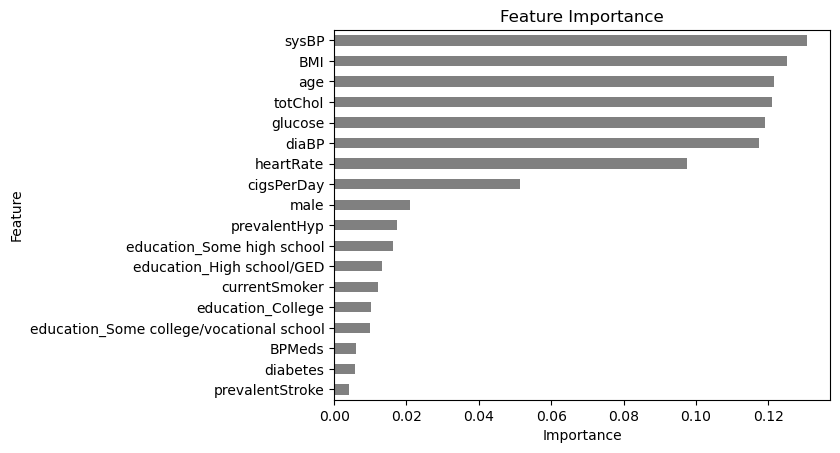

In [49]:
global_importances = pd.Series(rf_mod.feature_importances_, index=X_train.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='grey')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

#### Part (d) (10 points)

Suppose you wish to determine the “optimal” strategy for assigning which patients receive the medication. Given your colleague's analysis of the total expected economic costs associated with CHD and the medication, identify an appropriate threshold value of p. Provide the value of that threshold. Should the physician prescribe the preventive medication for the patient in Part (b)?

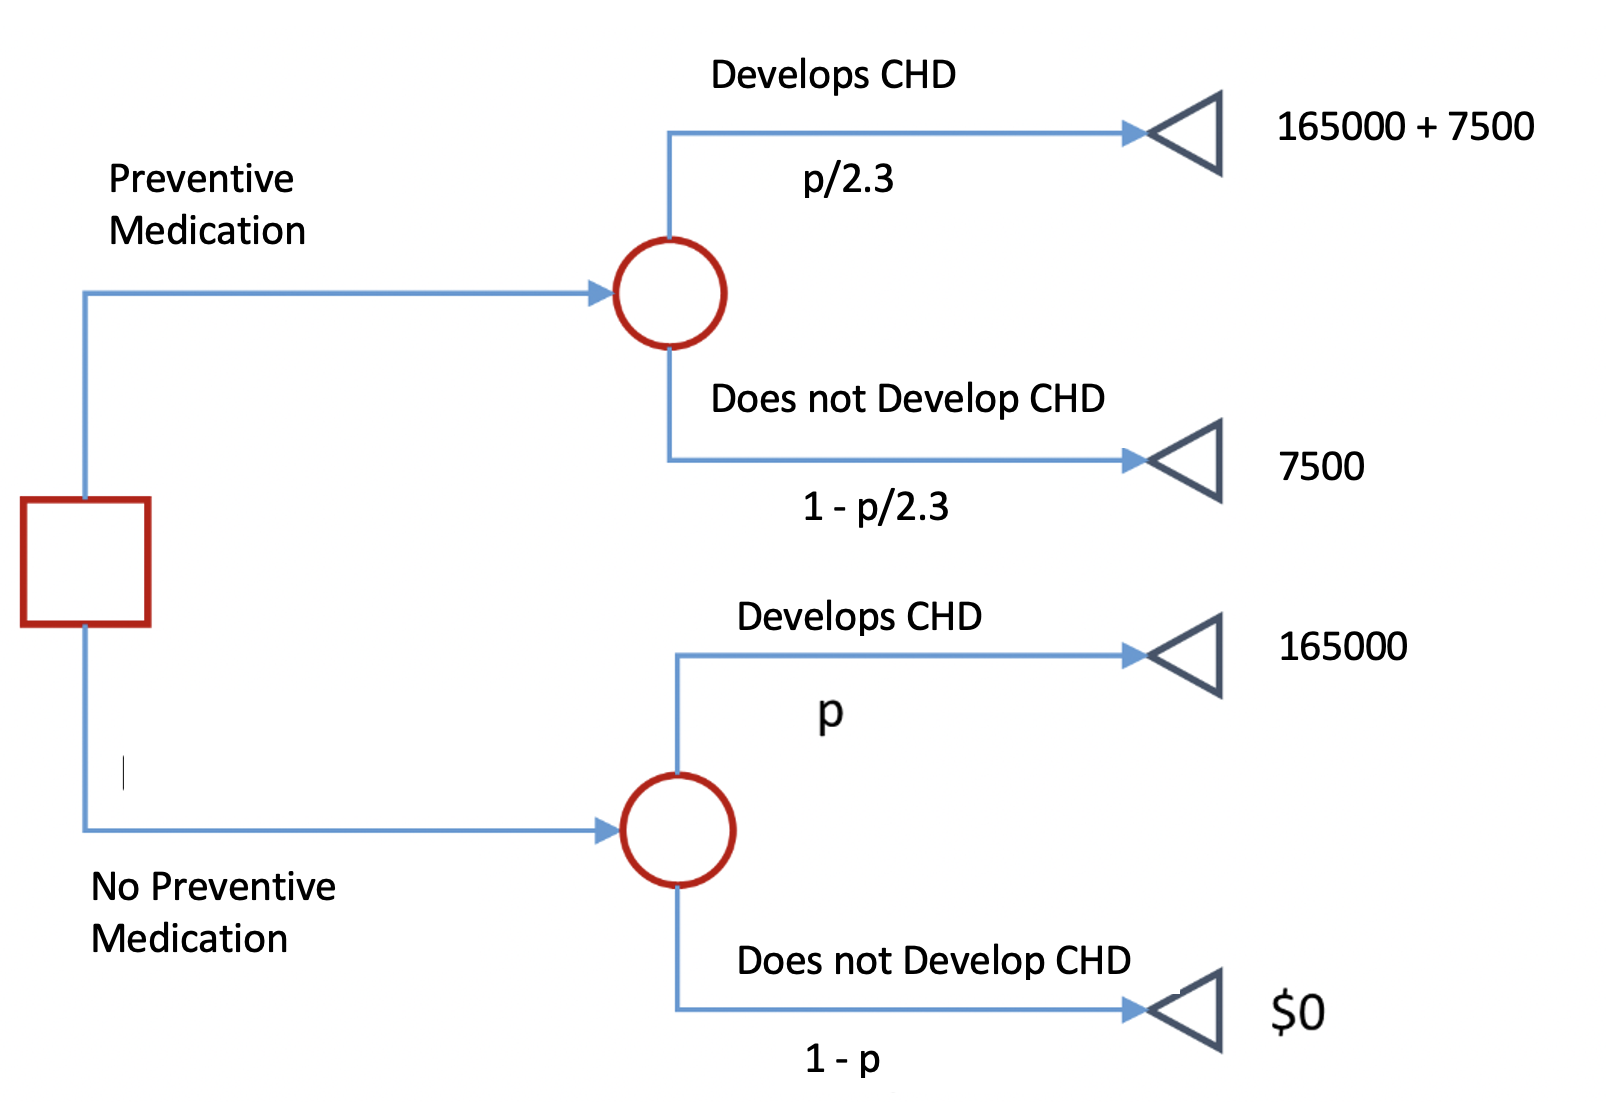

#### The expected cost of no-preventive medication is 165,000 p. The expected cost of preventive medication is 
#### 172500 * (p/2.3) + 7500 * (1 – p/2.3). 

#### The break-even probability is 0.0804. If p > 0.0804 then we consider high risk else low risk for CHD.

#### Yes, the physician should prescribe the preventive medication for the patient in Part (b) based on the threshold of 0.0804 as the predicted probability that the patient will experience CHD in the next ten years is 0.258.

#### Part (e) (10 points)

Describe the test-set performance of the random forest model, using the threshold identified in Part (d) to separate patients into those who are at high risk for CHD (risk exceeding the threshold p) and those who are at low risk for CHD (risk below the threshold p). Consider high risk as the “positive” outcome and low risk as the “negative” outcome. Calculate the model's accuracy, sensitivity, and specificity. 

In [50]:
X_test

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,education_College,education_High school/GED,education_Some college/vocational school,education_Some high school
0,1,52,0,0,0,0,1,0,260,141.5,89.0,26.36,76,79,0,0,0,1
1,0,38,1,20,0,0,1,0,221,140.0,90.0,21.35,95,70,0,1,0,0
2,1,48,1,10,0,0,1,0,232,138.0,90.0,22.37,64,72,0,0,1,0
3,0,52,1,20,0,0,0,0,215,132.0,82.0,25.11,71,75,0,0,1,0
4,0,61,0,0,0,0,1,0,272,182.0,121.0,32.80,85,65,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909,1,48,1,43,0,0,1,0,209,144.0,88.0,29.11,84,60,0,1,0,0
910,0,59,1,20,0,0,0,0,251,125.0,80.0,22.18,70,70,0,0,1,0
911,1,58,0,0,0,0,0,0,233,125.5,84.0,26.05,67,76,0,0,0,1
912,1,43,1,20,0,0,0,0,187,129.5,88.0,25.62,80,75,1,0,0,0


In [51]:
y_test

0      0
1      1
2      0
3      0
4      1
      ..
909    0
910    0
911    1
912    0
913    1
Name: TenYearCHD, Length: 914, dtype: int64

In [52]:
y_pred_rf_mod = rf_mod.predict_proba(X_test) 

In [53]:
y_pred_rf_mod

array([[0.834, 0.166],
       [0.952, 0.048],
       [0.773, 0.227],
       ...,
       [0.847, 0.153],
       [0.975, 0.025],
       [0.548, 0.452]])

In [54]:
mythreshold = 0.0804

In [55]:
rf_decisions = (y_pred_rf_mod[:,1] >= mythreshold).astype(int)
rf_decisions

array([1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,

In [56]:
rf_cm = confusion_matrix(y_test, rf_decisions)
rf_cm

array([[270, 502],
       [ 18, 124]])

In [57]:
accuracy_score(y_test, rf_decisions)

0.4310722100656455

In [58]:
sensitivity  = rf_cm[1,1]/ (rf_cm[1,1] + rf_cm[1,0]) 
sensitivity

0.8732394366197183

In [59]:
specificity  = rf_cm[0,0]/ (rf_cm[0,0] + rf_cm[0,1]) 
specificity

0.34974093264248707

#### Part (f) (5 points)

Are there any aspects of the analysis performed thus far that raise ethical concerns? If so, what are some ways that this analysis could be changed to address these concerns?

#### The Analysis is conducted focusing mainly on the costs and benfits of newly approved preventive medication and patients are considered high risk vs low risk purely based on the threshold, which is derived using the health economic study results. But a little importance is given to patient's autonomy, their financial condition keeping patient's best interest in mind. It also ignores the principle of justice that speaks to equity and fairness in treatment.

#### One way this analysis could be changed is by collecting additional qualitative data directly from the patients and using it in the model to classify patients.

---

### PROBLEM 3 (25 points)

Recall the Ames Iowa housing dataset <ames.csv> studied in Deliverable 3. In this problem, I ask you to build linear predictive models for median house value using regularization. 

Start by creating a random 80-20 train-test split of the dataset. Then fit a LASSO regression model on the training set, with λ chosen by (the default leave-on-out) cross-validation. Examine values of λ in the range [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e-0, 1e+1, 1e+2, 1e+3, 1e+4, 1e+5]. What is the best choice of λ in this range? What is the out-of-sample RMSE? What is the number of non-zero coefficient estimates for the LASSO model?

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

In [61]:
pd.options.display.max_columns = None

### Reading the data

In [62]:
df = pd.read_csv("ames.csv")

In [63]:
df.dropna(axis = 0, how = 'any', inplace = True) 

In [64]:
df = pd.get_dummies(df, drop_first=True)

In [65]:
df

,SalePrice,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,X1stFlrSF,X2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MoSold,YrSold,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_No Alley,Alley_Pave,LotShape_Mod+ IR,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Not Gtl,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Other,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_Other,Exterior1st_MetalSd,Exterior1st_Other,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_No Basement,BsmtQual_TA,BsmtCond_Gd,BsmtCond_No Basement,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No Basement,BsmtExposure_No Exposure,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_No Basement,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_No Basement,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_HotW,Heating_Other,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_TA,CentralAir_Y,Electrical_FF,Electrical_FP,Electrical_SB,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_No Fireplace,FireplaceQu_Po,FireplaceQu_TA,GarageType_A,GarageType_BI,GarageType_BM,GarageType_CP,GarageType_D,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_TA,PavedDrive_P,PavedDrive_Y,PoolQC_No Pool,PoolQC_TA,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_No Fence,MiscFeature_No Feature,SaleType_Other,SaleType_Warranty Deed
0,215000,141.0,31770,1960,1960,112,639,0,441,1080,1656,0,0,1656,1,0,1,0,3,1,7,2,1960,2,528,210,62,0,0,0,0,5,2010,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,1,0,1
1,105000,80.0,11622,1961,1961,0,468,144,270,882,896,0,0,896,0,0,1,0,2,1,5,0,1961,1,730,140,0,0,0,120,0,6,2010,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,1,1,0,0,1,0,0,1,0,1
2,172000,81.0,14267,1958,1958,108,923,0,406,1329,1329,0,0,1329,0,0,1,1,3,1,6,0,1958,1,312,393,36,0,0,0,0,6,2010,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0

In [66]:
y = df["SalePrice"]

In [67]:
X = df.drop("SalePrice", axis=1)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=886)

#### Standardizing the dataset

In [69]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [70]:
std_X_train = X_train.copy()
std_X_test = X_test.copy()

In [71]:
std_train_array = scaler.transform(std_X_train)
std_test_array = scaler.transform(std_X_test)

In [72]:
std_X_train[:] = std_train_array
std_X_test[:] = std_test_array

#### LASSO Regression

In [73]:
lambdas = np.logspace(-5, 5, 11)

In [74]:
lasso_mod_cv = LassoCV(alphas=lambdas, max_iter=1000000, tol = 0.01)

In [75]:
lasso_mod_cv.fit(std_X_train, y_train)

LassoCV(alphas=array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02,
       1.e+03, 1.e+04, 1.e+05]),
        max_iter=1000000, tol=0.01)

In [76]:
print("The best choice of λ is",lasso_mod_cv.alpha_)

The best choice of λ is 100.0


In [77]:
pred_test_lasso= lasso_mod_cv.predict(std_X_test)
print("The out of sample RMSE is", np.sqrt(mean_squared_error(y_test,pred_test_lasso))) 

The out of sample RMSE is 25467.732968791508


In [78]:
print("LASSO Regression with CV train R2: ", lasso_mod_cv.score(std_X_train, y_train))
print("LASSO Regression with CV test R2: ", lasso_mod_cv.score(std_X_test, y_test))

LASSO Regression with CV train R2:  0.8993780600591036
LASSO Regression with CV test R2:  0.8635919380945757


In [79]:
lasso_mod_cv.coef_

array([-1.40278365e+03,  2.29292209e+03,  5.50516612e+03,  4.84240179e+03,
        1.61315457e+02,  2.26041720e+03,  9.68967994e+02, -0.00000000e+00,
        3.08505220e+03,  1.14027259e+04,  1.40503120e+04,  0.00000000e+00,
        8.83671733e+03,  2.59190174e+03, -5.74354376e+02,  2.02055920e+03,
        5.97533073e+02, -9.32767291e+02, -2.87824098e+03, -5.27686034e+02,
        4.42805881e+03, -2.99015300e+02,  5.97381430e+03,  2.53143443e+03,
        1.34417578e+03, -8.48563830e+01,  8.96536633e+02,  5.82792363e+02,
        1.85506580e+03,  1.16566075e+04, -2.16695413e+02, -3.55581125e+02,
        8.80853034e+02, -7.73597049e+01,  9.35186324e+02,  1.54619933e+02,
        0.00000000e+00,  2.78399901e+02, -1.91674863e+02,  2.72219043e+03,
        8.98276492e+02,  2.38974881e+03,  6.23300179e+01, -8.23215264e+02,
       -4.74745648e+02, -0.00000000e+00,  8.45267696e+02,  6.15261475e+02,
        1.90765056e+03,  3.27559807e+01,  9.81500757e+02,  0.00000000e+00,
        4.25327256e+03, -

In [80]:
np.count_nonzero(lasso_mod_cv.coef_)

165

---
### END